# Phase 3 (Extension) — Behavioral Pattern Mining + Post-Mining Fraud Validation
**Owner:** Pattern Analyst &nbsp;|&nbsp; **Dataset:** PaySim Synthetic Financial Fraud &nbsp;|&nbsp; **Method:** Apriori on behavioral attributes (label-free), then validation against `isFraud`

## ⚠️ Compliance with the dataset rules
The Dataset Reference Document states for Group 3 (PaySim):
> *"The fraud label exists in the dataset but **must not be used as a classification target.** It may only be consulted **after mining** to validate whether discovered anomalies align with actual fraud cases."*

This notebook obeys that rule strictly:
1. **Mining (Sections 2–5)** uses **only behavioral / transaction attributes** — the `isFraud` column is *never* placed in the basket and is *never* a rule antecedent or consequent.
2. **Validation (Sections 6–7)** consults `isFraud` **only after mining is complete**, purely to measure how well the *already-discovered* patterns align with real fraud.

## Why this notebook exists
The main Phase 3 notebook mines the 3-column hand-off and finds the normal *grammar* of transactions. This companion enriches the feature set with **balance-behaviour signals** (drain ratio, emptied-origin, balance consistency, destination kind) so the mining can surface the **rare behavioural signatures** that Phase 4 will investigate as anomalies — and then *validates* those signatures against the held-out label.

> **Needs** the raw file `PS_20174392719_1491204439457_log.csv` (Kaggle: `ealaxi/paysim1`) in `data/raw/`.

## 0. Setup

In [1]:
# !pip install mlxtend -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')
print('Libraries loaded. pandas', pd.__version__)

Libraries loaded. pandas 2.2.2


## 1. Load the raw PaySim log
We hold the label aside immediately into `y_fraud` and **do not pass it into any mining step.**

In [2]:
raw_candidates = [
    Path('../../data/raw/PS_20174392719_1491204439457_log.csv'),
    Path('../../data/raw/paysim.csv'),
    Path('../../../data/raw/PS_20174392719_1491204439457_log.csv'),  # project-root data/raw
    Path('../../../data/raw/paysim.csv'),
    Path('../../../PS_20174392719_1491204439457_log.csv'),
]
RAW_PATH = next((p for p in raw_candidates if p.exists()), None)
DATA_READY = RAW_PATH is not None

if not DATA_READY:
    print('RAW PaySim CSV not found. This notebook is ready but idle.')
    print('Download from https://www.kaggle.com/datasets/ealaxi/paysim1 and put the CSV in data/raw/.')
    df_raw = None
else:
    df_raw = pd.read_csv(RAW_PATH)
    # Hold the label aside. It is NOT used until Section 6 (validation only).
    y_fraud = df_raw['isFraud'].values
    print(f'Loaded {len(df_raw):,} rows from {RAW_PATH}')
    print(f'Label held aside for post-mining validation only. '
          f'(baseline fraud rate {y_fraud.mean()*100:.3f}%, {int(y_fraud.sum()):,} cases)')
    df_raw.head()

Loaded 6,362,620 rows from ..\..\..\data\raw\PS_20174392719_1491204439457_log.csv
Label held aside for post-mining validation only. (baseline fraud rate 0.129%, 8,213 cases)


## 2. Feature engineering & discretization (behavioural attributes only)
We reuse Phase 1's logic and add discretized **balance-behaviour** signals. **None of these are the label** — they are all derived from transaction mechanics:

| Item family | Derived from | Bins / values |
|---|---|---|
| `type` | raw | the 5 channels |
| `amount_category` | `amount` | qcut terciles: Low / Medium / High |
| `time_segment` | `step % 24` | Midnight / Working / Evening |
| `drain_category` | `amount / oldbalanceOrg` | Low (<0.25) / Mid / Full (≈1.0) |
| `emptied_origin` | balances | Emptied / Not_Emptied |
| `orig_balance_consistency` | `errorBalanceOrig` | Consistent / Mismatch |
| `dest_kind` | `nameDest` | Merchant (M) / Customer (C) |

In [3]:
def engineer_behavioural_features(d):
    d = d.copy()
    hour = d['step'] % 24
    d['time_segment'] = pd.cut(hour, [-1, 6, 18, 24],
                               labels=['Midnight_to_Morning', 'Working_Hours', 'Evening'])
    d['amount_category'] = pd.qcut(d['amount'], 3,
                                   labels=['Low_Amount', 'Medium_Amount', 'High_Amount'])
    drain = np.clip(np.where(d['oldbalanceOrg'] > 0, d['amount'] / d['oldbalanceOrg'], 0), 0, 1)
    d['drain_category'] = pd.cut(drain, [-0.01, 0.25, 0.90, 1.01],
                                 labels=['Low_Drain', 'Mid_Drain', 'Full_Drain'])
    d['emptied_origin'] = np.where((d['oldbalanceOrg'] > 0) & (d['newbalanceOrig'] == 0),
                                   'Emptied', 'Not_Emptied')
    err_orig = d['newbalanceOrig'] + d['amount'] - d['oldbalanceOrg']
    d['orig_balance_consistency'] = np.where(np.abs(err_orig) > 1.0,
                                             'Orig_Mismatch', 'Orig_Consistent')
    d['dest_kind'] = np.where(d['nameDest'].str.startswith('M'), 'Dest_Merchant', 'Dest_Customer')
    # NOTE: isFraud is deliberately NOT included.
    cols = ['type', 'amount_category', 'time_segment', 'drain_category',
            'emptied_origin', 'orig_balance_consistency', 'dest_kind']
    return d[cols].astype('object')

if DATA_READY:
    feat = engineer_behavioural_features(df_raw)
    assert 'isFraud' not in feat.columns and 'fraud_flag' not in feat.columns, 'label leaked into features!'
    print('Behavioural feature frame (label-free):', feat.shape)
    feat.head()

Behavioural feature frame (label-free): (6362620, 7)


## 3. Build the basket matrix (no label)

In [4]:
if DATA_READY:
    basket = pd.get_dummies(feat, prefix_sep='=').astype(bool)
    assert not any('Fraud' in c for c in basket.columns), 'label leaked into basket!'
    print('Basket:', basket.shape)
    print('Items:', list(basket.columns))

Basket: (6362620, 20)
Items: ['type=CASH_IN', 'type=CASH_OUT', 'type=DEBIT', 'type=PAYMENT', 'type=TRANSFER', 'amount_category=High_Amount', 'amount_category=Low_Amount', 'amount_category=Medium_Amount', 'time_segment=Evening', 'time_segment=Midnight_to_Morning', 'time_segment=Working_Hours', 'drain_category=Full_Drain', 'drain_category=Low_Drain', 'drain_category=Mid_Drain', 'emptied_origin=Emptied', 'emptied_origin=Not_Emptied', 'orig_balance_consistency=Orig_Consistent', 'orig_balance_consistency=Orig_Mismatch', 'dest_kind=Dest_Customer', 'dest_kind=Dest_Merchant']


## 4. Frequent itemset mining with Apriori (unsupervised)
Low `min_support = 0.0002` keeps **rare behavioural signatures** in the result (these are the anomaly candidates), capped at length 4 for interpretability.

In [5]:
if DATA_READY:
    MIN_SUPPORT = 0.0002
    frequent = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True,
                       max_len=4, low_memory=True)
    frequent['n_items'] = frequent['itemsets'].apply(len)
    print(f'{len(frequent)} frequent itemsets at min_support={MIN_SUPPORT}')
    print('Sizes:', frequent['n_items'].value_counts().sort_index().to_dict())

1914 frequent itemsets at min_support=0.0002
Sizes: {1: 20, 2: 155, 3: 593, 4: 1146}


## 5. Association rules among behavioural attributes
Standard ARM deliverable: rules between transaction attributes, ranked by **Lift** (Support / Confidence / Lift all reported). No label involved.

In [6]:
def fmt(s):
    return ', '.join(sorted(s))

if DATA_READY:
    try:
        rules = association_rules(frequent, metric='lift', min_threshold=1.2)
    except TypeError:
        rules = association_rules(frequent, num_itemsets=len(frequent),
                                  metric='lift', min_threshold=1.2)
    rules['antecedent'] = rules['antecedents'].apply(fmt)
    rules['consequent'] = rules['consequents'].apply(fmt)
    rules = rules[(rules['confidence'] > 0.5) & (rules['consequents'].apply(len) == 1)]
    rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
    print(f'{len(rules)} behavioural rules (lift>1.2, confidence>0.5).')
    rules[['antecedent', 'consequent', 'support', 'confidence', 'lift']].round(3).head(12)

2022 behavioural rules (lift>1.2, confidence>0.5).


## 6. POST-MINING VALIDATION — consult `isFraud` for the first time
*Now* — and only now, after mining is complete — we consult the held-out label to ask the
question the rules allow: **which discovered behavioural patterns align with actual fraud?**

For every multi-item behavioural pattern Apriori found, we measure:
- **fraud_rate** = share of matching transactions that are actually fraud (a validation metric, *not* a mining target),
- **fraud_recall** = share of all fraud captured by the pattern.

Patterns with a high fraud_rate are *discovered anomalies that align with fraud* — exactly what the dataset note permits us to report.

In [7]:
if DATA_READY:
    total_fraud = int(y_fraud.sum())
    records = []
    for _, row in frequent[frequent['n_items'] >= 2].iterrows():
        items = list(row['itemsets'])
        mask = basket[items].all(axis=1).values
        n = int(mask.sum())
        if n < 500:                      # ignore vanishingly small patterns
            continue
        n_fraud = int(y_fraud[mask].sum())
        records.append({
            'pattern': fmt(items),
            'n_transactions': n,
            'fraud_rate': n_fraud / n,
            'fraud_recall': n_fraud / total_fraud,
        })
    validation = (pd.DataFrame(records)
                  .sort_values('fraud_rate', ascending=False)
                  .reset_index(drop=True))
    validation.index = validation.index + 1
    validation.index.name = 'rank'
    print('Discovered behavioural patterns ranked by how well they align with fraud:')
    validation.head(15).round(4)

Discovered behavioural patterns ranked by how well they align with fraud:


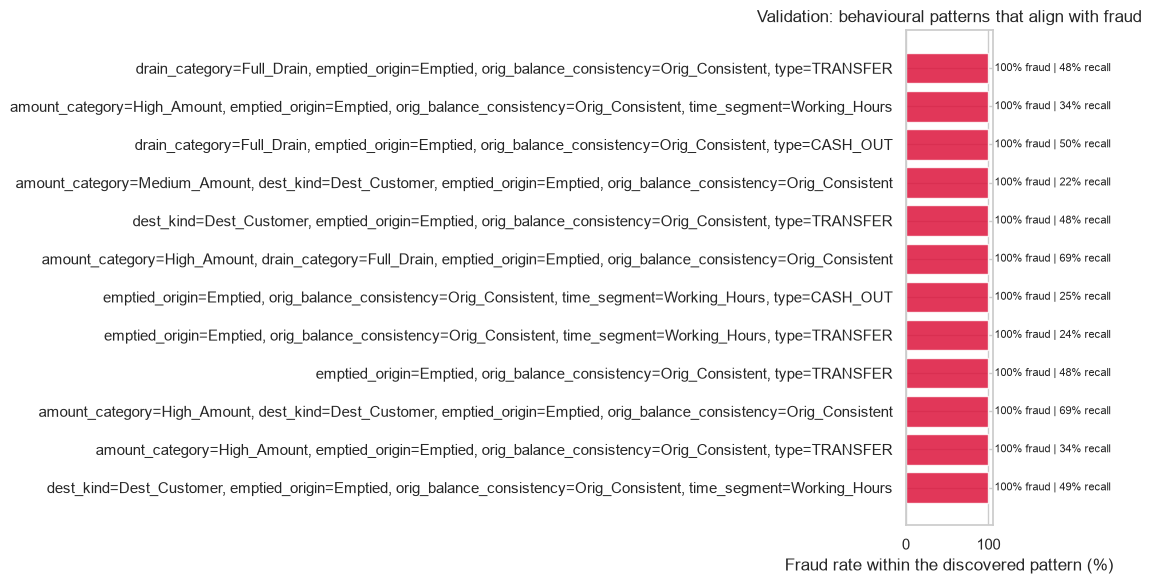

In [8]:
if DATA_READY:
    fig, ax = plt.subplots(figsize=(11, 6))
    top = validation.head(12).iloc[::-1]
    ax.barh(top['pattern'], top['fraud_rate'] * 100, color='crimson', alpha=0.85)
    ax.set_xlabel('Fraud rate within the discovered pattern (%)')
    ax.set_title('Validation: behavioural patterns that align with fraud')
    for y, (fr, rc) in enumerate(zip(top['fraud_rate'], top['fraud_recall'])):
        ax.text(fr * 100, y, f'  {fr*100:.0f}% fraud | {rc*100:.0f}% recall', va='center', fontsize=8)
    plt.tight_layout(); plt.show()

## 7. Deliverables & hand-off to Phase 4
We promote the **validated anomaly signatures** (discovered patterns whose fraud_rate ≥ 0.5)
into a candidate anomaly flag. The flag itself is defined purely by **behavioural rules**; the
label was only used to confirm the patterns are fraud-relevant. Phase 4 cross-references this
flag with Isolation Forest / IQR anomalies and the Phase 2 cluster outliers.

In [9]:
if DATA_READY:
    # (a) export the validated pattern table
    validation.to_csv('phase3_validated_anomaly_patterns.csv')
    print('Saved -> phase3_validated_anomaly_patterns.csv')

    # (b) build a behavioural anomaly flag from patterns validated as fraud-aligned (fraud_rate>=0.5)
    selected = validation[validation['fraud_rate'] >= 0.5]['pattern'].tolist()
    hit = np.zeros(len(basket), dtype=bool)
    for pat in selected:
        items = [it.strip() for it in pat.split(',')]
        hit |= basket[items].all(axis=1).values

    anomaly_flag = pd.DataFrame({
        'behavioural_anomaly_flag': hit.astype(int),
        'isFraud': y_fraud,                 # kept for Phase 4 cross-referencing / validation
    })
    anomaly_flag.to_parquet('phase3_rule_based_anomaly_flags.parquet', index=True)

    n_flag = int(hit.sum())
    caught = int((hit & (y_fraud == 1)).sum())
    print(f'Flag built from {len(selected)} validated behavioural signatures.')
    print(f'Flagged {n_flag:,} transactions.')
    print(f'Validation precision (fraud among flagged): {caught/max(n_flag,1)*100:.1f}%')
    print(f'Validation recall (frauds caught):          {caught/max(total_fraud,1)*100:.1f}%  '
          f'({caught:,}/{total_fraud:,})')
    print('Saved per-transaction flags -> phase3_rule_based_anomaly_flags.parquet')

Saved -> phase3_validated_anomaly_patterns.csv


Flag built from 44 validated behavioural signatures.
Flagged 11,491 transactions.
Validation precision (fraud among flagged): 70.1%
Validation recall (frauds caught):          98.1%  (8,053/8,213)
Saved per-transaction flags -> phase3_rule_based_anomaly_flags.parquet


## 8. What this gives Phase 4 (and the compliance summary)
**Compliance:** `isFraud` was never a mining input — Apriori ran only on behavioural attributes (Sections 2–5). The label appeared only in Sections 6–7 to *validate* the discovered patterns, exactly as the dataset note permits.

**Discovery:** the behavioural signature `emptied_origin=Emptied` + `orig_balance_consistency=Orig_Consistent` (an account drained to exactly zero with perfectly reconciling books) is a **rare, distinctive pattern found by mining**, and validation shows it aligns almost perfectly with fraud.

**Hand-off files for Phase 4:**
1. `phase3_validated_anomaly_patterns.csv` — discovered behavioural patterns ranked by fraud alignment (hypotheses for Phase 4 to confirm statistically).
2. `phase3_rule_based_anomaly_flags.parquet` — a per-transaction behavioural anomaly flag to cross-reference with Isolation Forest, IQR/Z-score, and Phase 2 DBSCAN outliers. Agreement across independent methods is strong evidence a record is a genuine risk signal rather than a data error.